In [1]:
import tensorflow as tf
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print(tf.__version__)

ModuleNotFoundError: No module named 'tensorflow'

In [2]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

<Axes: ylabel='count'>

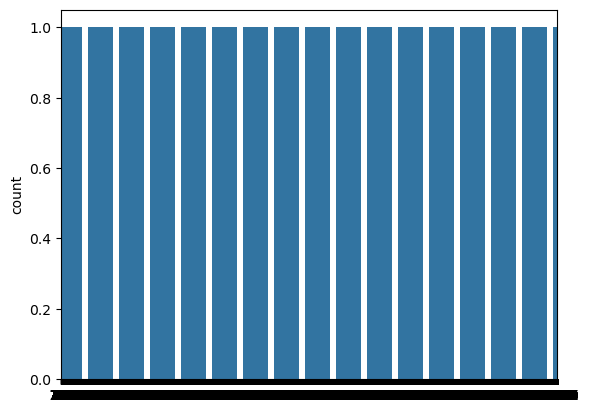

In [3]:
sns.countplot(y_train)

In [4]:
input_shape = (28, 28, 1)

x_train=x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
x_train=x_train / 255.0
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)
x_test = x_test / 255.0

In [5]:
y_train = tf.one_hot(y_train.astype(np.int32), depth=10)
y_test = tf.one_hot(y_test.astype(np.int32), depth=10)

W0000 00:00:1771940483.302029  516828 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


tf.Tensor([0. 0. 0. 0. 0. 1. 0. 0. 0. 0.], shape=(10,), dtype=float32)


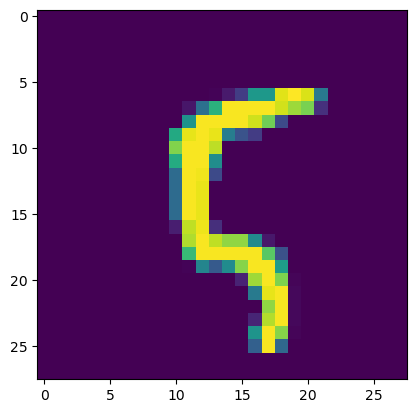

In [6]:
plt.imshow(x_train[100][:,:,0])
print(y_train[100])

In [7]:
batch_size = 64
num_classes = 10
epochs = 5

In [10]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (5,5), padding='same', activation='relu', input_shape=input_shape),
    tf.keras.layers.Conv2D(32, (5,5), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(strides=(2,2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.RMSprop(epsilon=1e-08), loss='categorical_crossentropy', metrics=['acc'])

In [13]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('acc')>0.995):
            print("\nReached 99.5% accuracy so cancelling training!")
            self.model.stop_training = True

callbacks = myCallback()

In [14]:
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1, callbacks=[callbacks])

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 53s 61ms/step - acc: 0.9306 - loss: 0.2227 - val_acc: 0.9875 - val_loss: 0.0394
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - acc: 0.9775 - loss: 0.0760 - val_acc: 0.9887 - val_loss: 0.0380
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 61ms/step - acc: 0.9832 - loss: 0.0574 - val_acc: 0.9915 - val_loss: 0.0329
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 62ms/step - acc: 0.9858 - loss: 0.0491 - val_acc: 0.9920 - val_loss: 0.0312
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - acc: 0.9868 - loss: 0.0455 - val_acc: 0.9922 - val_loss: 0.0285


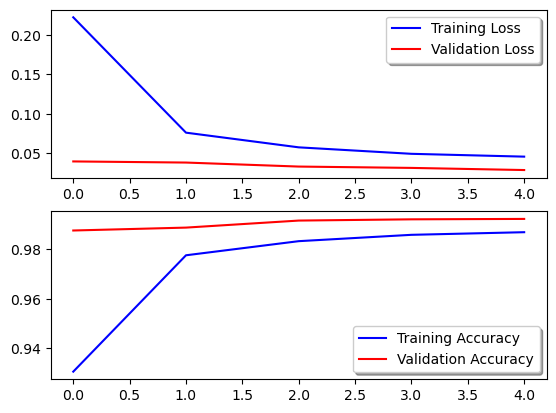

In [17]:
fig, ax = plt.subplots(2,1)
ax[0].plot(history.history['loss'], color='b', label="Training Loss")
ax[0].plot(history.history['val_loss'], color='r', label="Validation Loss")
legend = ax[0].legend(loc='best', shadow=True)

ax[1].plot(history.history['acc'], color='b', label="Training Accuracy")
ax[1].plot(history.history['val_acc'], color='r',label="Validation Accuracy")
legend = ax[1].legend(loc='best', shadow=True)

In [18]:
test_loss, test_acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - acc: 0.9930 - loss: 0.0231


In [20]:
Y_pred = model.predict(x_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(y_test, axis=1)
confusion_mtx = tf.math.confusion_matrix(Y_true, Y_pred_classes)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


<Axes: >

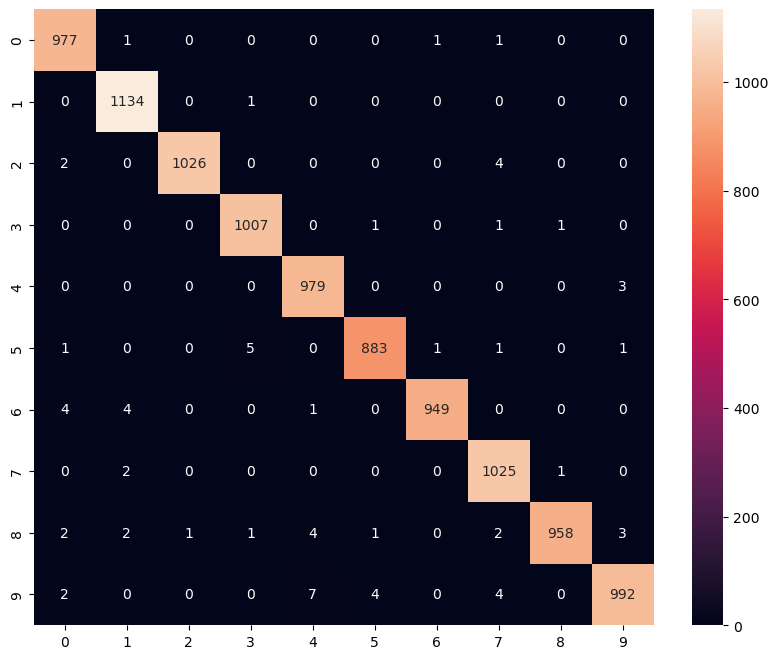

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(confusion_mtx, annot=True, fmt='g')